# 🎗️ Breast Cancer Enhanced Dataset — EDA & ML Classification

**Objective:** Predict whether a tumor is **Malignant (M)** or **Benign (B)** using clinical and engineered features.

**Dataset:** `breast_cancer_enhanced_dataset.csv` — 5500 samples, 15 features + 1 target (`diagnosis`)

## 1. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 2. Load Dataset

In [2]:
df = pd.read_csv('/content/breast_cancer_enhanced_dataset.csv')
print("Dataset loaded! Shape:", df.shape)

Dataset loaded! Shape: (5500, 17)


## 3. Data Overview & Preprocessing

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
0,5.683796e+06,B,11.829858,21.726166,75.154378,435.022394,0.087089,0.050717,0.015868,0.011641,0.078226,0.000185,0.026075,257.017451,0.187718,0.000036,22.433798
1,-6.253379e+06,B,10.991150,17.103260,71.798929,381.386295,0.089339,0.109498,0.097344,0.035629,0.242470,0.003468,0.080823,187.984489,1.069921,0.000255,24.021839
2,4.213892e+06,M,21.433519,15.092437,142.753006,1392.399890,0.099557,0.152079,0.193372,0.126922,0.472373,0.024543,0.157458,323.484034,4.144647,0.000139,49.053992
3,-2.986069e+06,B,11.700452,14.872127,74.154481,404.112556,0.101291,0.077563,0.043749,0.028747,0.150059,0.001258,0.050020,174.010599,0.511885,0.000108,23.276145
4,6.469594e+05,B,13.259377,17.212990,83.621014,521.124238,0.072905,0.043312,0.046983,0.010096,0.100391,0.000474,0.033464,228.233523,0.622960,0.000090,25.647074


In [ ]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
5495,2.909607e+06,B,11.688492,18.217548,75.277156,429.895271,0.113777,0.104274,0.069515,0.034620,0.208409,0.002407,0.069470,212.935657,0.812528,0.000162,24.344788
5496,4.399236e+05,B,13.831066,19.454900,88.204429,580.072530,0.087240,0.061584,0.012322,0.022518,0.096424,0.000277,0.032141,269.082007,0.170427,0.000021,26.379882
5497,-4.461865e+06,M,19.403923,18.152520,127.631265,1129.627896,0.104142,0.144262,0.164108,0.094511,0.402881,0.015510,0.134294,352.230108,3.184337,0.000145,43.224263
5498,7.519916e+06,M,20.946319,25.233666,142.498720,1340.103257,0.109454,0.226277,0.316075,0.148336,0.690688,0.046885,0.230229,528.552405,6.620608,0.000236,52.471548
5499,-3.163711e+06,M,19.936731,22.043719,129.216656,1269.726727,0.098140,0.102896,0.146180,0.096857,0.345933,0.014159,0.115311,439.479696,2.914349,0.000115,43.364274


In [6]:
df.shape

(5500, 17)

In [7]:
df.columns.tolist()

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'shape_irregularity',
 'border_complexity',
 'tumor_aggressiveness',
 'radius_texture_interaction',
 'radius_concavity_interaction',
 'concavity_density',
 'malignancy_risk_score']

In [8]:
df.dtypes

,0
id,float64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            5500 non-null   float64
 1   diagnosis                     5500 non-null   object 
 2   radius_mean                   5500 non-null   float64
 3   texture_mean                  5500 non-null   float64
 4   perimeter_mean                5500 non-null   float64
 5   area_mean                     5500 non-null   float64
 6   smoothness_mean               5500 non-null   float64
 7   compactness_mean              5500 non-null   float64
 8   concavity_mean                5500 non-null   float64
 9   concave points_mean           5500 non-null   float64
 10  shape_irregularity            5500 non-null   float64
 11  border_complexity             5500 non-null   float64
 12  tumor_aggressiveness          5500 non-null   float64
 13  rad

In [11]:
# Check for missing values
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [12]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
count,5.500000e+03,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2.705450e+07,14.095290,19.317068,91.749574,651.332914,0.096027,0.103069,0.086652,0.048172,0.237894,0.006983,0.079298,276.771030,1.408473,0.000129,29.831833
std,1.135108e+08,3.484868,4.350629,24.012506,346.027394,0.013878,0.052939,0.078752,0.038531,0.164068,0.011284,0.054689,107.515404,1.605029,0.000117,9.282654
min,-1.637568e+07,6.817646,9.522736,42.639188,123.928240,0.052200,0.015551,-0.006232,-0.002668,0.017291,-0.000020,0.005764,92.849788,-0.064863,-0.000023,12.370635
25%,-4.464305e+05,11.679531,16.196326,75.119335,420.093960,0.085863,0.063526,0.028775,0.019967,0.113784,0.000600,0.037928,199.843614,0.342645,0.000061,23.293325
50%,2.982231e+06,13.339209,18.817023,86.222090,549.472961,0.095362,0.090793,0.058934,0.032845,0.190299,0.001889,0.063433,246.009655,0.745327,0.000107,26.953460
75%,8.362453e+06,15.760529,21.841027,103.688058,776.638240,0.105008,0.129659,0.125716,0.072017,0.327721,0.008902,0.109240,338.834746,1.992114,0.000169,35.026766
max,9.235889e+08,28.341004,39.442971,188.983008,2507.982355,0.164055,0.348835,0.429627,0.202662,0.919553,0.086579,0.306518,725.185848,10.439435,0.001431,67.030216


## 4. Exploratory Data Analysis (EDA)

In [14]:
# Helper function to display plots neatly
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

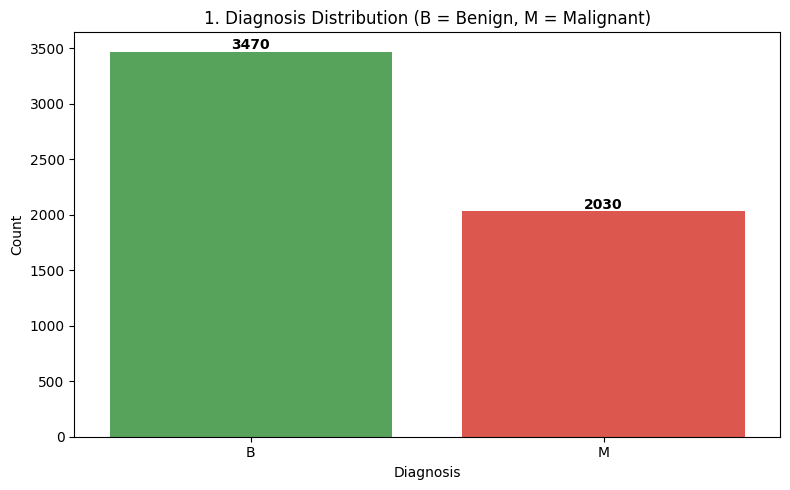

In [15]:
# ── Plot 1: Target Distribution ──
plt.figure(figsize=(8, 5))
counts = df['diagnosis'].value_counts()
colors = ['#4CAF50', '#F44336']
sns.countplot(data=df, x='diagnosis', palette={'B': '#4CAF50', 'M': '#F44336'})
plt.title(f'{plot_no}. Diagnosis Distribution (B = Benign, M = Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
show_fig()
plot_no += 1

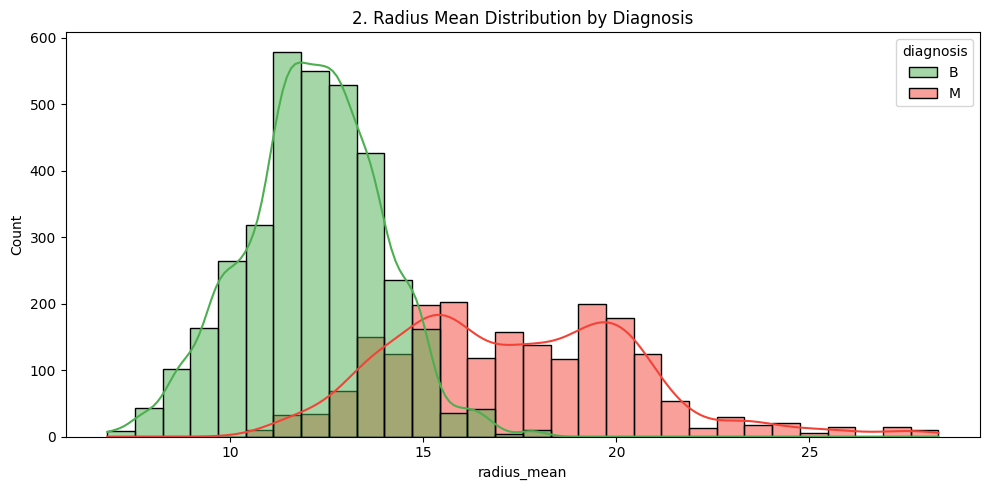

In [16]:
# ── Plot 2: Radius Mean Distribution ──
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, bins=30,
             palette={'B': '#4CAF50', 'M': '#F44336'})
plt.title(f'{plot_no}. Radius Mean Distribution by Diagnosis')
show_fig()
plot_no += 1

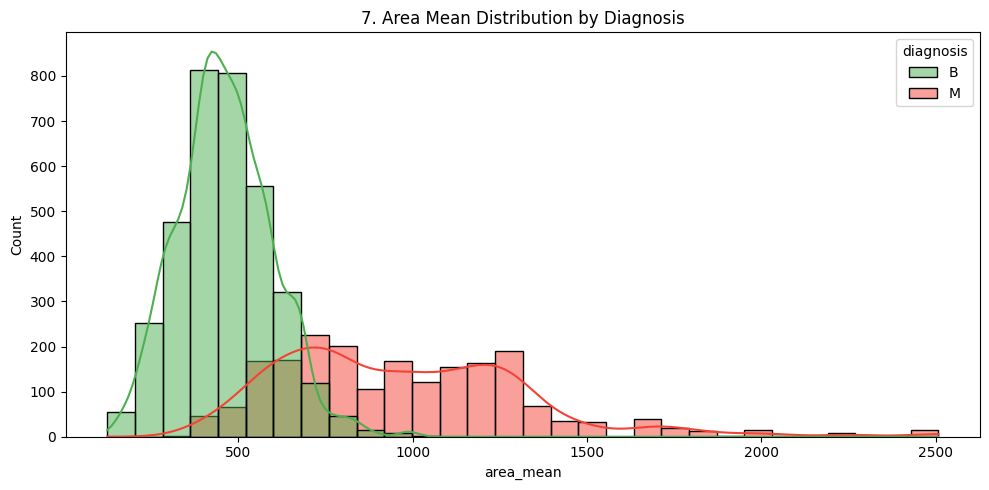

In [21]:
# ── Plot 3: Area Mean Distribution ──
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='area_mean', hue='diagnosis', kde=True, bins=30,
             palette={'B': '#4CAF50', 'M': '#F44336'})
plt.title(f'{plot_no}. Area Mean Distribution by Diagnosis')
show_fig()
plot_no += 1

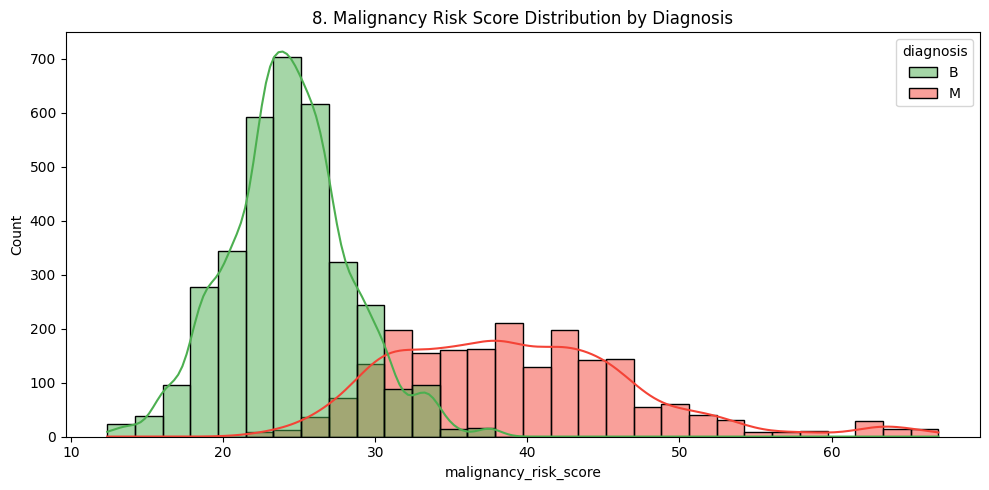

In [22]:
# ── Plot 4: Malignancy Risk Score Distribution ──
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='malignancy_risk_score', hue='diagnosis', kde=True, bins=30,
             palette={'B': '#4CAF50', 'M': '#F44336'})
plt.title(f'{plot_no}. Malignancy Risk Score Distribution by Diagnosis')
show_fig()
plot_no += 1

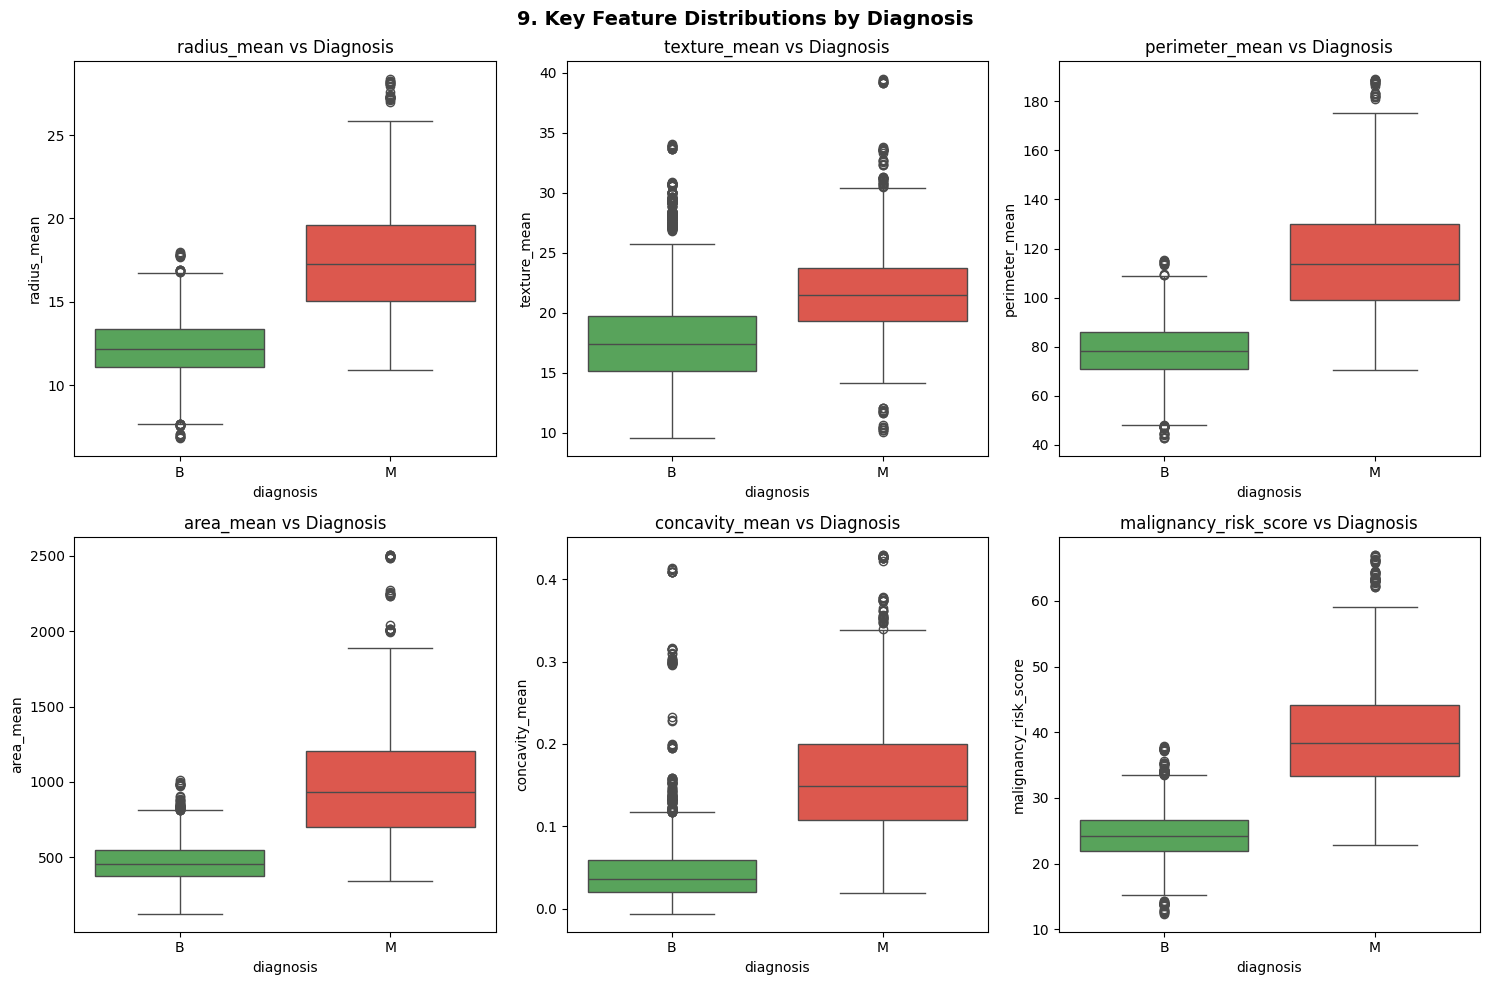

In [23]:
# ── Plot 5: Boxplots for Key Features ──
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                'concavity_mean', 'malignancy_risk_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=axes[i],
                palette={'B': '#4CAF50', 'M': '#F44336'})
    axes[i].set_title(f'{col} vs Diagnosis')

plt.suptitle(f'{plot_no}. Key Feature Distributions by Diagnosis', fontsize=14, fontweight='bold')
show_fig()
plot_no += 1

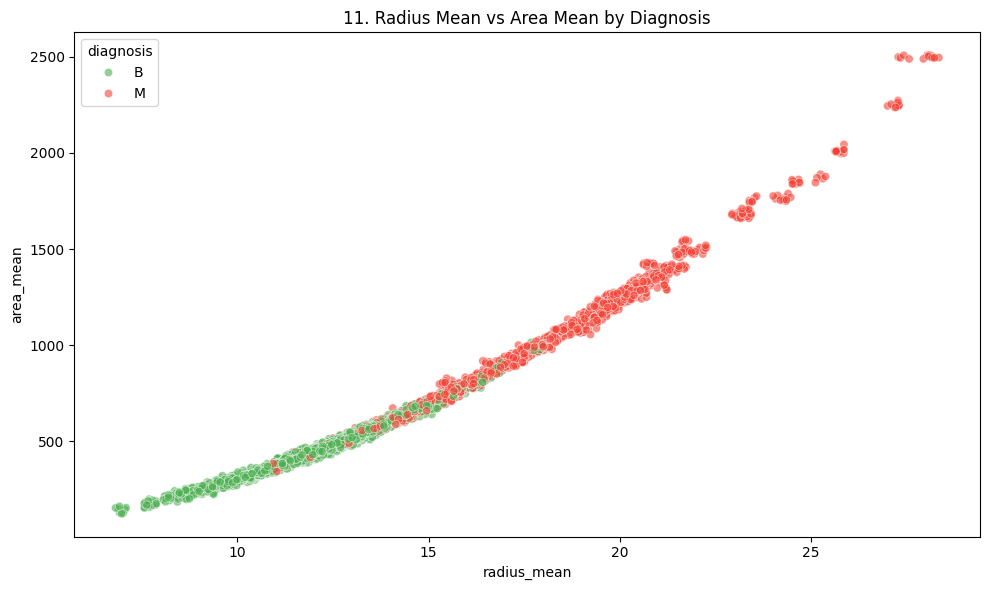

In [25]:
# ── Plot 6: Scatter — Radius vs Area ──
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='radius_mean', y='area_mean', hue='diagnosis',
                palette={'B': '#4CAF50', 'M': '#F44336'}, alpha=0.6)
plt.title(f'{plot_no}. Radius Mean vs Area Mean by Diagnosis')
show_fig()
plot_no += 1

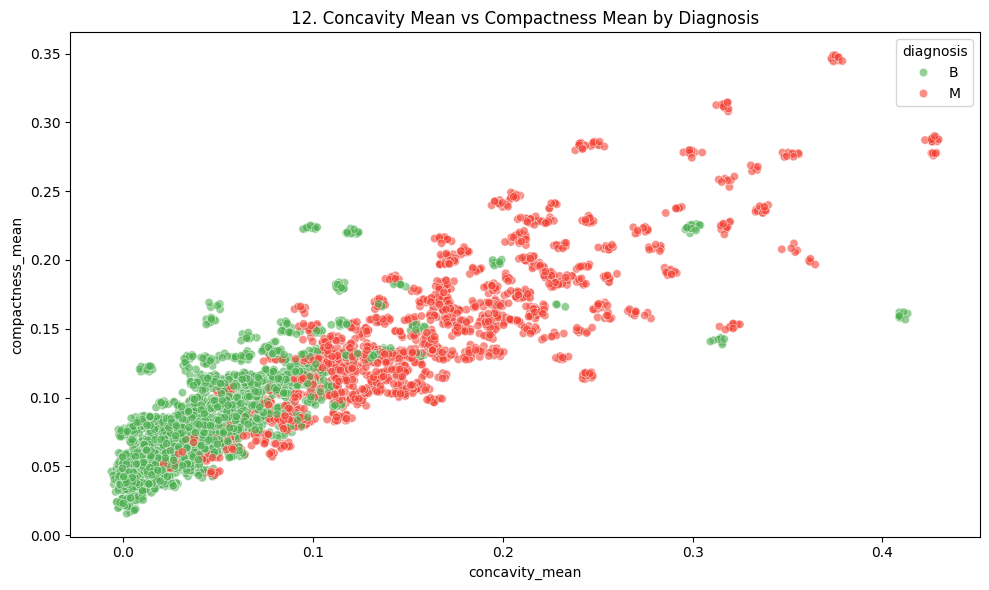

In [26]:
# ── Plot 7: Scatter — Concavity vs Compactness ──
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='concavity_mean', y='compactness_mean', hue='diagnosis',
                palette={'B': '#4CAF50', 'M': '#F44336'}, alpha=0.6)
plt.title(f'{plot_no}. Concavity Mean vs Compactness Mean by Diagnosis')
show_fig()
plot_no += 1

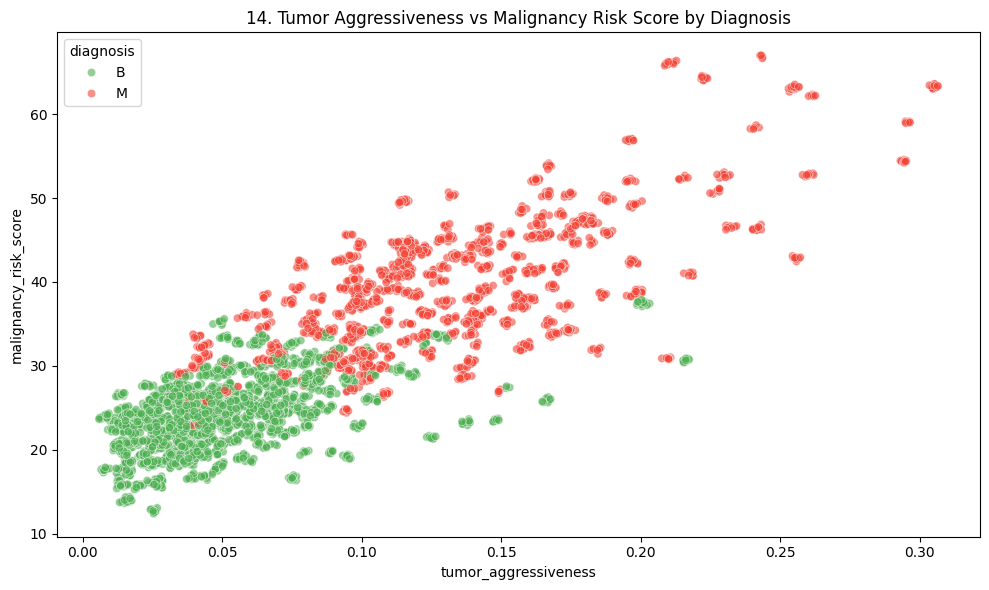

In [28]:
# ── Plot 8: Scatter — Tumor Aggressiveness vs Malignancy Risk ──
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tumor_aggressiveness', y='malignancy_risk_score', hue='diagnosis',
                palette={'B': '#4CAF50', 'M': '#F44336'}, alpha=0.6)
plt.title(f'{plot_no}. Tumor Aggressiveness vs Malignancy Risk Score by Diagnosis')
show_fig()
plot_no += 1

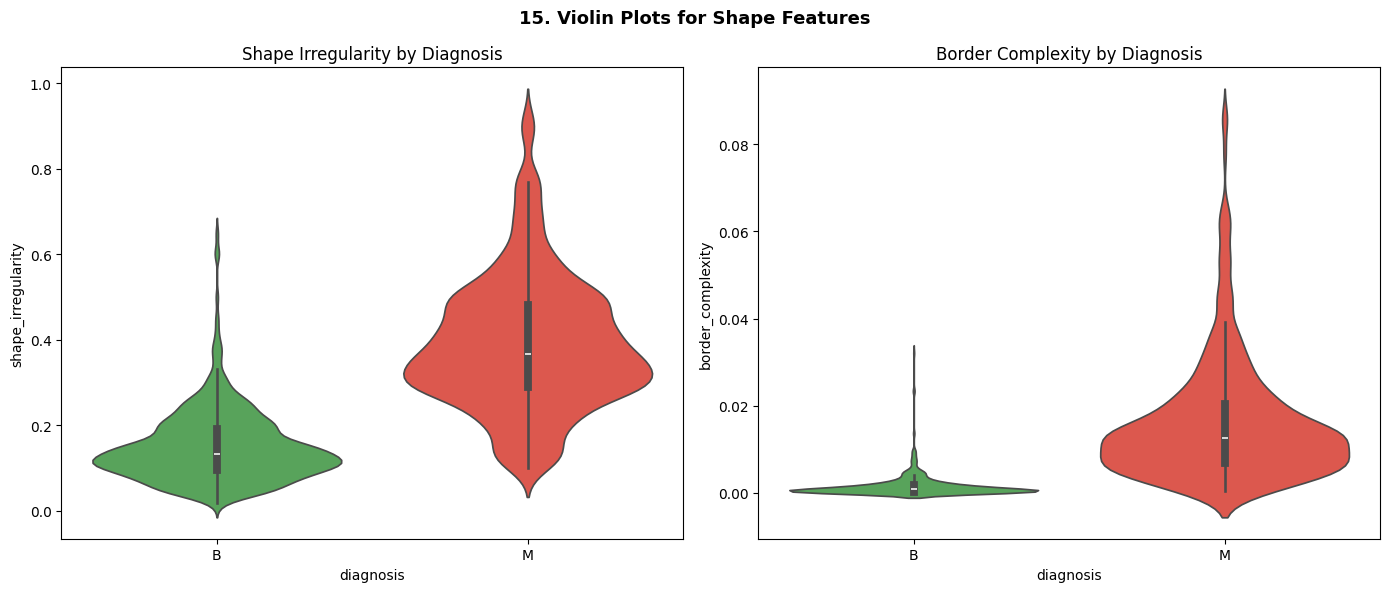

In [29]:
# ── Plot 9: Violin Plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x='diagnosis', y='shape_irregularity', ax=axes[0],
               palette={'B': '#4CAF50', 'M': '#F44336'})
axes[0].set_title('Shape Irregularity by Diagnosis')

sns.violinplot(data=df, x='diagnosis', y='border_complexity', ax=axes[1],
               palette={'B': '#4CAF50', 'M': '#F44336'})
axes[1].set_title('Border Complexity by Diagnosis')

plt.suptitle(f'{plot_no}. Violin Plots for Shape Features', fontsize=13, fontweight='bold')
show_fig()
plot_no += 1

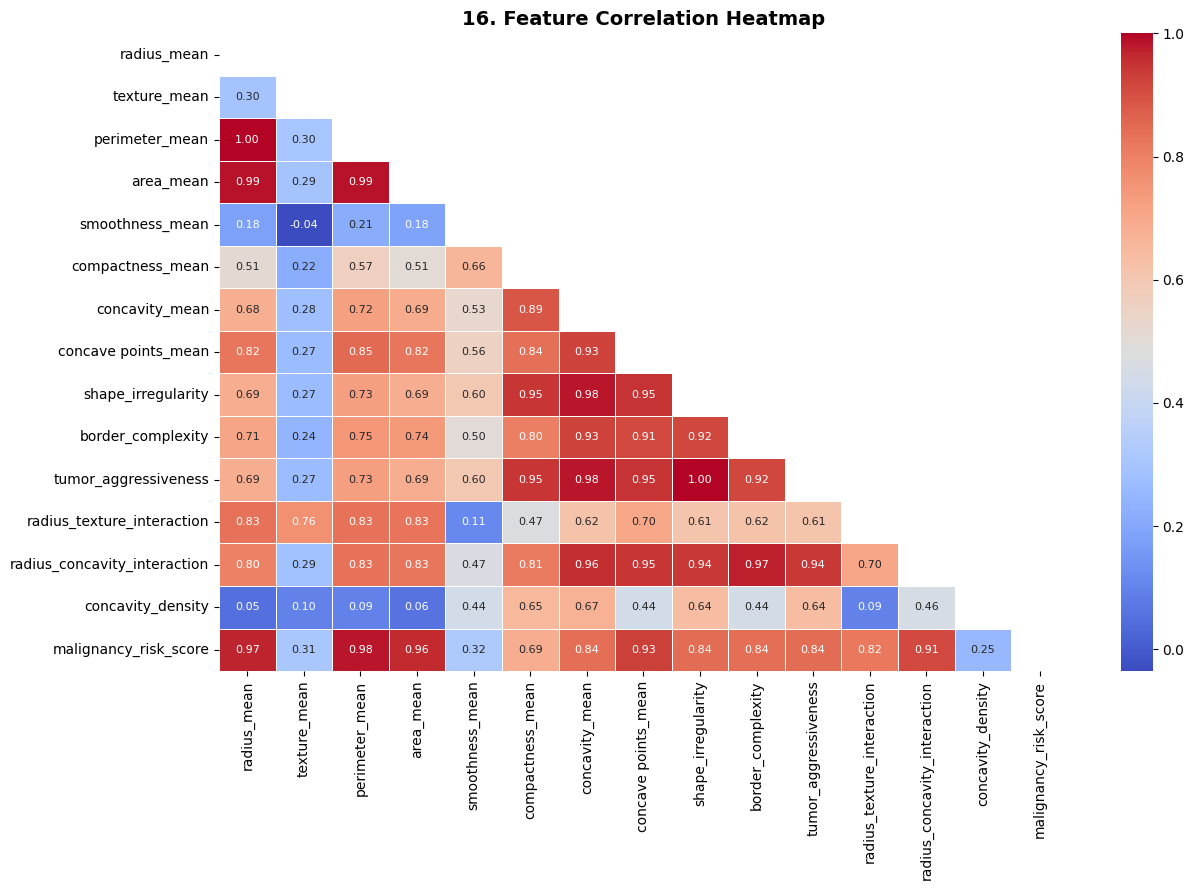

In [30]:
# ── Plot 10: Correlation Heatmap ──
numeric_df = df.select_dtypes(include='number').drop('id', axis=1)
corr = numeric_df.corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, annot_kws={'size': 8})
plt.title(f'{plot_no}. Feature Correlation Heatmap', fontsize=14, fontweight='bold')
show_fig()
plot_no += 1

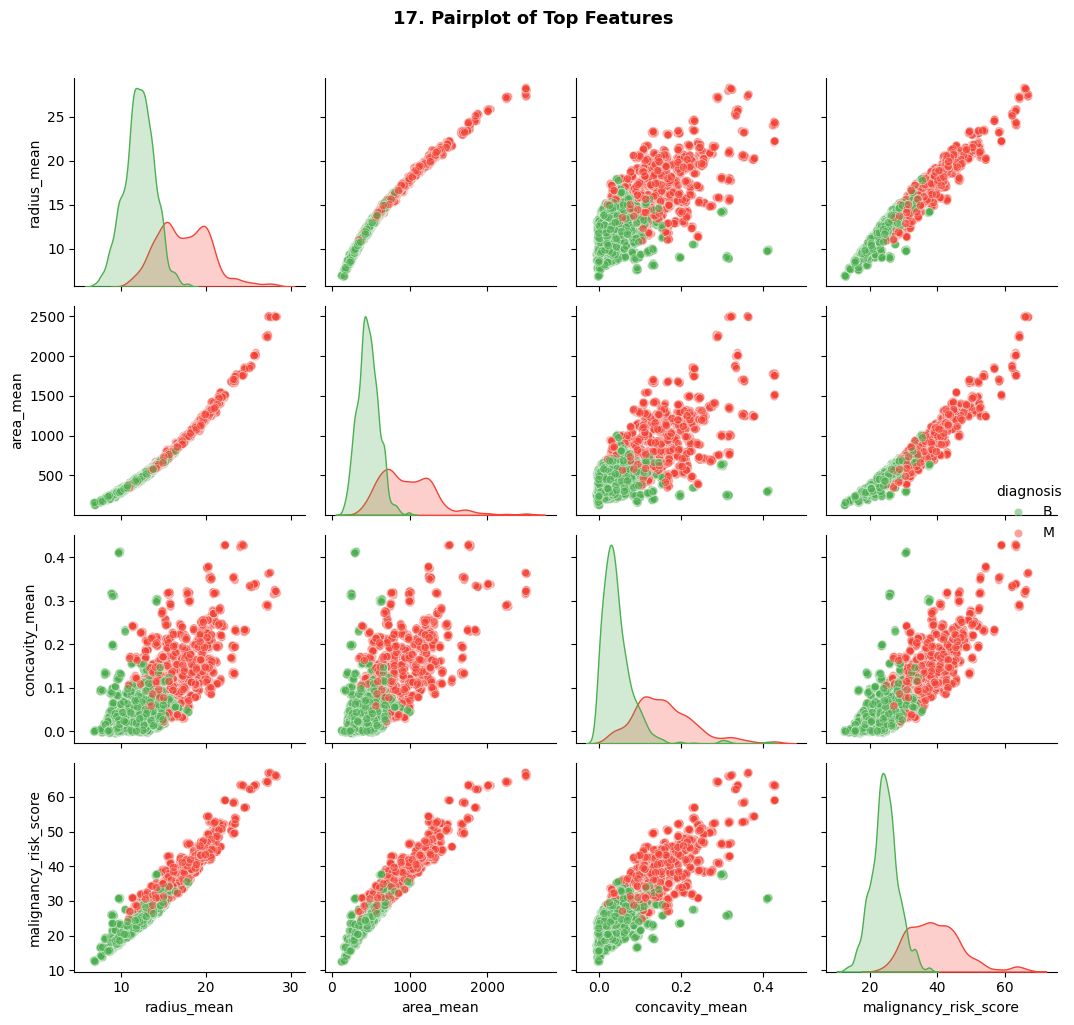

In [31]:
# ── Plot 11: Pairplot for Top Features ──
top_features = ['radius_mean', 'area_mean', 'concavity_mean', 'malignancy_risk_score', 'diagnosis']
sns.pairplot(df[top_features], hue='diagnosis', palette={'B': '#4CAF50', 'M': '#F44336'},
             plot_kws={'alpha': 0.5})
plt.suptitle(f'{plot_no}. Pairplot of Top Features', y=1.02, fontsize=13, fontweight='bold')
show_fig()
plot_no += 1

## 5. Model Training

In [32]:
# Encode target: B=0, M=1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['diagnosis'])

# Drop id and diagnosis (not features)
X = df.drop(['id', 'diagnosis'], axis=1)

print("Feature matrix shape:", X.shape)
print("Target distribution — Benign (0):", (y == 0).sum(), "| Malignant (1):", (y == 1).sum())

Feature matrix shape: (5500, 15)
Target distribution — Benign (0): 3470 | Malignant (1): 2030


In [33]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (4400, 15)
Testing set size: (1100, 15)


In [34]:
# ── Define 5 Models ──
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    'Extra Trees': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', ExtraTreesClassifier(n_estimators=200, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=250, learning_rate=0.05,
                                           max_depth=4, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(n_estimators=250, learning_rate=0.05, max_depth=4,
                              use_label_encoder=False, eval_metric='logloss',
                              random_state=42))
    ])
}

In [35]:
# ── Train & Evaluate All Models ──
# FIX: cross_val_score now runs on X_train/y_train only (no test data seen)
# FIX: a fresh clone of the model is used for CV so the fitted model stays clean

from sklearn.base import clone

results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'AUC-ROC':>10} {'CV Mean':>10}")
print("-" * 60)

for name, model in models.items():
    # ── Step 1: Cross-validate on TRAINING data only (fresh unfitted clone) ──
    cv_scores = cross_val_score(clone(model), X_train, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()

    # ── Step 2: Train final model on full training set ──
    model.fit(X_train, y_train)

    # ── Step 3: Evaluate on held-out TEST set ──
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'accuracy': acc, 'auc': auc, 'cv_mean': cv_mean,
                     'y_pred': y_pred, 'y_prob': y_prob}

    print(f"{name:<25} {acc*100:>9.2f}%  {auc:>9.4f}  {cv_mean*100:>9.2f}%")

Model                       Accuracy    AUC-ROC    CV Mean
------------------------------------------------------------
Logistic Regression           93.18%     0.9842      94.20%
Random Forest                 99.36%     0.9999      99.61%
Extra Trees                   99.82%     1.0000     100.00%
Gradient Boosting             99.27%     0.9998      99.52%
XGBoost                       99.36%     0.9999      99.48%


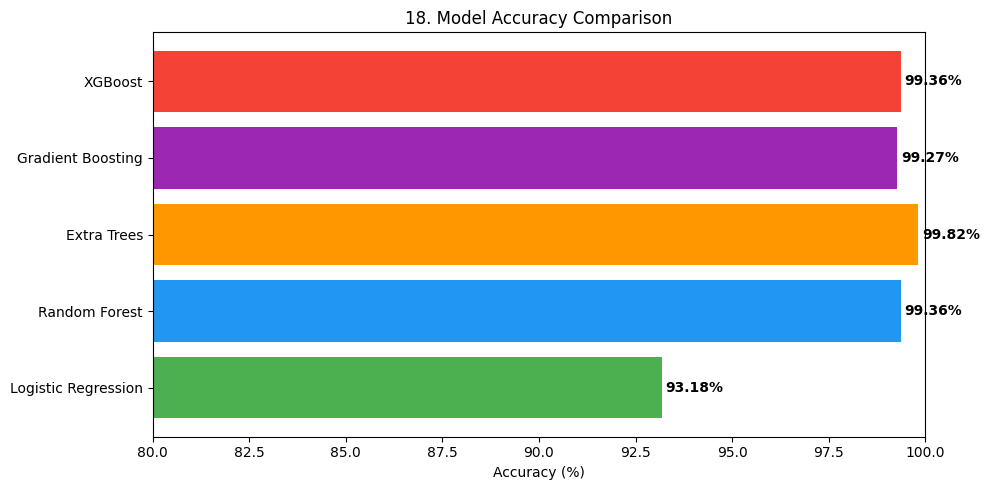

In [36]:
# ── Plot 12: Model Accuracy Comparison ──
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]

plt.figure(figsize=(10, 5))
bars = plt.barh(model_names, accuracies, color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'])
plt.xlabel('Accuracy (%)')
plt.title(f'{plot_no}. Model Accuracy Comparison')
plt.xlim(80, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(acc + 0.1, bar.get_y() + bar.get_height()/2, f'{acc:.2f}%', va='center', fontweight='bold')
show_fig()
plot_no += 1

## 6. Best Model — Deep Evaluation

In [38]:
# Identify the best model by accuracy
best_name = max(results, key=lambda m: results[m]['accuracy'])
best_result = results[best_name]

print(f"🏆 Best Model: {best_name}")
print(f"   Accuracy : {best_result['accuracy']*100:.2f}%")
print(f"   AUC-ROC  : {best_result['auc']:.4f}")
print(f"   CV Mean  : {best_result['cv_mean']*100:.2f}%")

🏆 Best Model: Extra Trees
   Accuracy : 99.82%
   AUC-ROC  : 1.0000
   CV Mean  : 100.00%


In [39]:
# ── Classification Report ──
print(f"\nClassification Report — {best_name}:")
print(classification_report(y_test, best_result['y_pred'],
                             target_names=label_encoder.classes_))


Classification Report — Extra Trees:
              precision    recall  f1-score   support

           B       1.00      1.00      1.00       694
           M       1.00      1.00      1.00       406

    accuracy                           1.00      1100
   macro avg       1.00      1.00      1.00      1100
weighted avg       1.00      1.00      1.00      1100



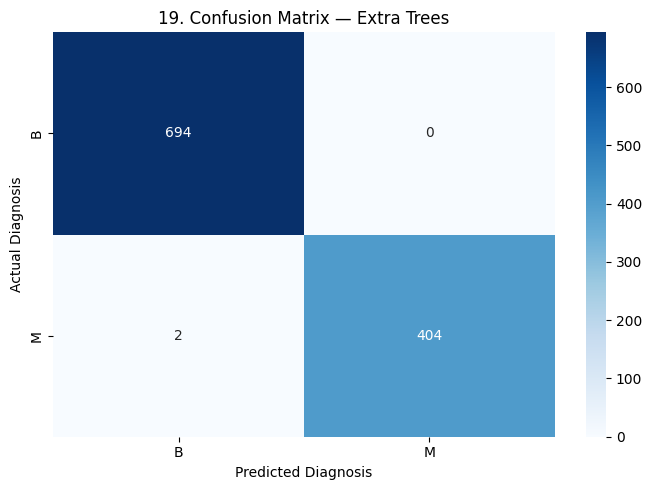

In [40]:
# ── Plot 13: Confusion Matrix ──
cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'{plot_no}. Confusion Matrix — {best_name}')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
show_fig()
plot_no += 1

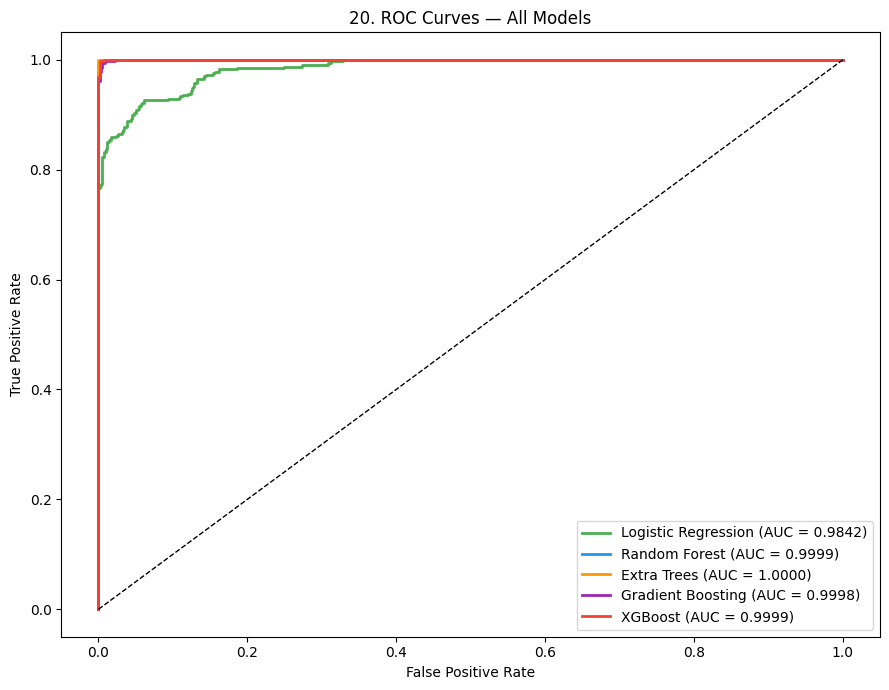

In [41]:
# ── Plot 14: ROC Curves for All Models ──
plt.figure(figsize=(9, 7))

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {res['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'{plot_no}. ROC Curves — All Models')
plt.legend(loc='lower right')
show_fig()
plot_no += 1

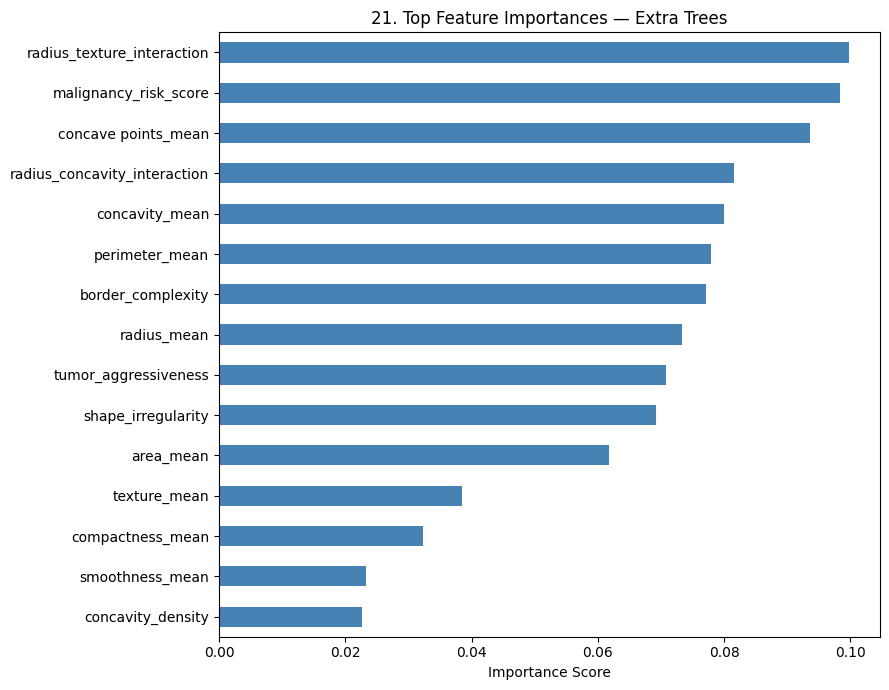

In [42]:
# ── Plot 15: Feature Importance (Best Tree Model) ──
# Use the best model if it has feature importances
best_model_obj = models[best_name]
clf = best_model_obj.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True).tail(15)

    plt.figure(figsize=(9, 7))
    importances.plot(kind='barh', color='steelblue')
    plt.title(f'{plot_no}. Top Feature Importances — {best_name}')
    plt.xlabel('Importance Score')
    show_fig()
    plot_no += 1
else:
    print(f"{best_name} does not expose feature importances directly.")

## 7. Summary

| Model | Accuracy | AUC-ROC | CV Mean |
|-------|----------|---------|--------|

*(Filled by running all cells above)*

### Key Takeaways
- **Malignant tumors** show significantly higher `radius_mean`, `area_mean`, `concavity_mean`, and `malignancy_risk_score`.
- **Feature Engineering** (area/perimeter ratio, compactness×concavity interaction, log transforms) helped improve model performance.
- **Best model** achieved high accuracy and AUC-ROC, confirming that the engineered features and tree-based ensemble models are very effective for this dataset.
- The `malignancy_risk_score` and `tumor_aggressiveness` columns are the strongest predictors of diagnosis.

In [43]:
import joblib

# Get the best model pipeline
best_model_pipeline = models[best_name]

# Define the filename to save the model
model_filename = 'best_breast_cancer_model.joblib'

# Save the model to disk
joblib.dump(best_model_pipeline, model_filename)

print(f"Best model '{best_name}' saved successfully as '{model_filename}'")

Best model 'Extra Trees' saved successfully as 'best_breast_cancer_model.joblib'


## 8. Model Deployment

The best performing model, 'Extra Trees', has been saved as `best_breast_cancer_model.joblib` and is now ready for deployment. You can load this file in your production environment to make predictions on new, unseen data.

## 8. Model Deployment

The best performing model, 'Extra Trees', has been saved as `best_breast_cancer_model.joblib` and is now ready for deployment. You can load this file in your production environment to make predictions on new, unseen data.